根据每局比赛的过程值预测比赛结果

In [1]:
%pip install shap
import shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df_moves = pd.read_parquet(r'..\df_moves6.parquet')

In [3]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

In [4]:
df_moves = df_moves[['uid', 'Move_Idx', 'Player', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Move_Time',
       'Game_Length', 'Progress', 'Is_check', 'Is_checkmate', 'Result', 'D', 'Cog_Speed']]
df_moves.head()

,uid,Move_Idx,Player,Is_Error,Is_Blunder,Δi,Δ,ELO,Is_Forced,Is_Optimal,Remain_Time,Move_Time,Game_Length,Progress,Is_check,Is_checkmate,Result,D,Cog_Speed
0,34,1,Dennis Wagner,0,0,3.0,6.0,2802.0,0,1,179.800003,1.2,63,0.015873,0,0,win,0.833333,0.69
1,34,2,Petar Ratkovic,0,0,3.0,4.0,2463.0,0,1,177.800003,3.2,63,0.031746,0,0,lose,0.882353,0.28
2,34,3,Dennis Wagner,0,0,6.0,7.0,2802.0,0,1,178.500000,2.3,63,0.047619,0,0,win,0.810811,0.35
3,34,4,Petar Ratkovic,0,0,14.0,38.0,2463.0,0,0,178.699997,0.1,63,0.063492,0,0,lose,0.441176,NaN
4,34,5,Dennis Wagner,0,0,12.0,15.0,2802.0,0,0,179.199997,0.3,63,0.079365,0,0,win,0.666667,NaN


In [5]:
df_moves['Result'].values

['win', 'lose', 'win', 'lose', 'win', ..., 'draw', 'draw', 'draw', 'draw', 'draw']
Length: 88912034
Categories (3, object): ['draw', 'lose', 'win']

In [6]:
for col in ['uid', 'Player', 'node_score']:
    if col in df_moves.columns:
        if df_moves[col].dtype == 'int64':
            df_moves[col] = pd.to_numeric(df_moves[col], downcast='integer')
        if df_moves[col].dtype == 'float64':
            df_moves[col] = pd.to_numeric(df_moves[col], downcast='float')

In [7]:
# 1. 提取微型数据框并预过滤
mask = df_moves['Progress'] >= 0.5
slim_df = df_moves.loc[mask, ['uid', 'Player', 'Progress', 'Move_Idx', 'Remain_Time']]

# 2. 计算残差
time_baseline = df_moves.groupby('Move_Idx')['Remain_Time'].mean().astype('float32')
slim_df['Expected_Remain'] = slim_df['Move_Idx'].map(time_baseline)
slim_df['Time_Residual'] = slim_df['Remain_Time'] - slim_df['Expected_Remain']

progress_stones = [0.6, 0.7, 0.8, 0.9]
tm_scores_list = []

# 3. 迭代计算每个节点的得分，存入列表
for p in progress_stones:
    # 【修正处】先将绝对值距离算成一列 'dist'
    slim_df['dist'] = (slim_df['Progress'] - p).abs()
    
    # 然后再按照 'dist' 列去找最小值对应的索引
    idx = slim_df.groupby(['uid', 'Player'], observed=True)['dist'].idxmin()
    
    # 提取这些行
    target_rows = slim_df.loc[idx]
    
    # 计算得分，统一列名 node_score，方便后续直接纵向求和
    target_rows['node_score'] = (target_rows['Time_Residual'] / 180.0) * target_rows['Progress']
    tm_scores_list.append(target_rows[['uid', 'Player', 'node_score']])

# 4. 纵向合并代替横向合并 (避免由于 merge 造成的内存爆炸)
all_nodes_df = pd.concat(tm_scores_list, ignore_index=True)

# 聚合出最终的局级时间管理分
game_level_tm = all_nodes_df.groupby(['uid', 'Player'], observed=True)['node_score'].sum().reset_index()
game_level_tm.rename(columns={'node_score': 'Time_Management_Score'}, inplace=True)
game_level_tm['Time_Management_Score'] = game_level_tm['Time_Management_Score'].round(2)

# 及时清理内存
del slim_df, time_baseline, tm_scores_list, all_nodes_df
gc.collect()

# 5. 将计算好的局级分数左连接合并回 df_moves
df_moves = df_moves.merge(game_level_tm, on=['uid', 'Player'], how='left')
del game_level_tm
gc.collect()

print("Step 3: 时间管理分计算完成！")

Step 3: 时间管理分计算完成！


In [8]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Move_Time', 'Game_Length',
       'Progress', 'Is_check', 'Is_checkmate', 'Result', 'D', 'Cog_Speed',
       'Time_Management_Score'],
      dtype='object')

In [9]:
# result结果映射
result_map = {'win': 1, 'lose': -1, 'draw': 0}
df_moves['Target'] = df_moves['Result'].map(result_map).astype('float32')

# 1. 核心聚合：加上 observed=True 规避内存爆炸
# 将单步特征求平均 (mean)，将局级特征取第一个值 (first)
game_features = df_moves.groupby(['uid', 'Player'], observed=True).agg({
    'Is_Optimal': 'mean',
    'Is_Error': 'mean', 
    'Is_Blunder': 'mean',
    'Δi': 'mean',           # 注意：你下面的 feature_cols 里有它，所以这里必须加上
    'D': 'mean',
    'Cog_Speed': 'mean',
    'Time_Management_Score': 'first', # 因为这一局里每步的这个分数都一样，取首个即可
    'ELO': 'first',
    'Target': 'first'
}).reset_index()

# 1. 核心特征列表：直接把 'ELO' 加进来！
features_to_diff = [
    'ELO', # <--- 直接加在这里
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 
    'Δi', 'D', 'Cog_Speed', 'Time_Management_Score'
]

# 2. 提取对手信息表 (不需要再单独拼凑 'ELO' 了)
opponent_cols = ['uid', 'Player'] + features_to_diff
opponent_info = game_features[opponent_cols].copy()

# 批量重命名 (不需要再单独写 'Opponent_ELO'，它会被自动重命名为 'Opp_ELO')
rename_dict = {'Player': 'Opponent'}
for col in features_to_diff:
    rename_dict[col] = f'Opp_{col}'
opponent_info.rename(columns=rename_dict, inplace=True)

# 3. 通过 uid 关联，把对手的数据拼到同一行
game_features = game_features.merge(opponent_info, on='uid', how='inner')

# 过滤掉“自己对自己”的行
game_features = game_features[game_features['Player'] != game_features['Opponent']].copy()

# 4. 批量计算 Diff 特征 (一个 for 循环搞定所有差值，包括 ELO_Diff)
for col in features_to_diff:
    game_features[f'{col}_Diff'] = game_features[col] - game_features[f'Opp_{col}']

# 5. 清理战场：把所有 Opp_ 开头的列直接干掉
cols_to_drop = [f'Opp_{col}' for col in features_to_diff]
game_features.drop(columns=cols_to_drop, inplace=True)

# 清理内存
del opponent_info
gc.collect()

print("加入对抗 Diff 后的特征列：")
print(game_features.columns.tolist())

加入对抗 Diff 后的特征列：
['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 'Cog_Speed', 'Time_Management_Score', 'ELO', 'Target', 'Opponent', 'ELO_Diff', 'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff']


In [10]:
game_features = game_features.drop(columns=['Opponent'])
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,Cog_Speed,Time_Management_Score,ELO,Target,ELO_Diff,Is_Optimal_Diff,Is_Error_Diff,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_Diff,Time_Management_Score_Diff
1,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,0.347500,0.22,2637.0,1.0,460.0,0.076923,-0.153846,-0.153846,-36.307693,-0.113450,-0.186136,-0.02
2,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.533636,0.24,2177.0,-1.0,-460.0,-0.076923,0.153846,0.153846,36.307693,0.113450,0.186136,0.02
5,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.396667,-0.06,2195.0,-1.0,-444.0,-0.109890,0.236264,0.230769,768.620911,-0.061178,0.065417,-0.20
6,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,0.331250,0.14,2639.0,1.0,444.0,0.109890,-0.236264,-0.230769,-768.620911,0.061178,-0.065417,0.20
9,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,0.229286,0.41,2049.0,-1.0,-558.0,0.236842,0.005263,0.055263,32.728951,-0.071206,-0.137714,0.11


In [11]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'Cog_Speed', 'Time_Management_Score', 'ELO', 'Target', 'ELO_Diff',
       'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff',
       'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff'],
      dtype='object')

In [12]:
game_features.shape

(2014682, 19)

## 二分类

[LightGBM] [Info] Number of positive: 734019, number of negative: 734813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 1468832, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499730 -> initscore=-0.001081
[LightGBM] [Info] Start training from score -0.001081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.120885

【单局胜负预测结果】
准确率 (Accuracy): 0.9549
AUC Score: 0.9908


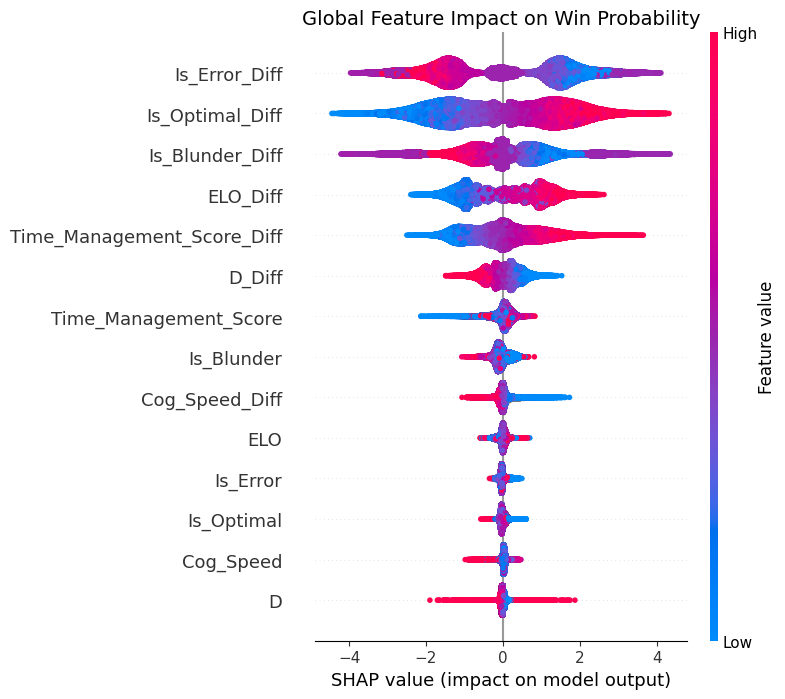

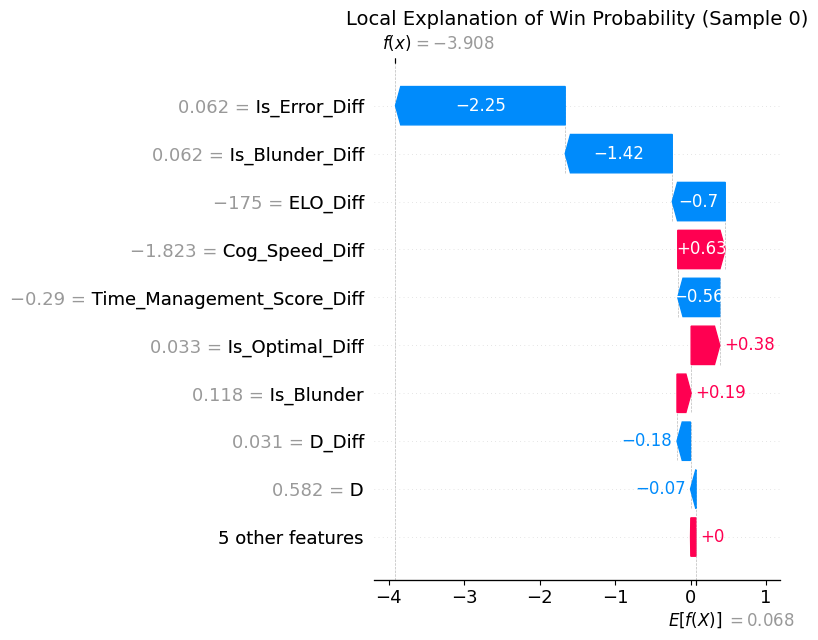

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


<Figure size 800x600 with 0 Axes>

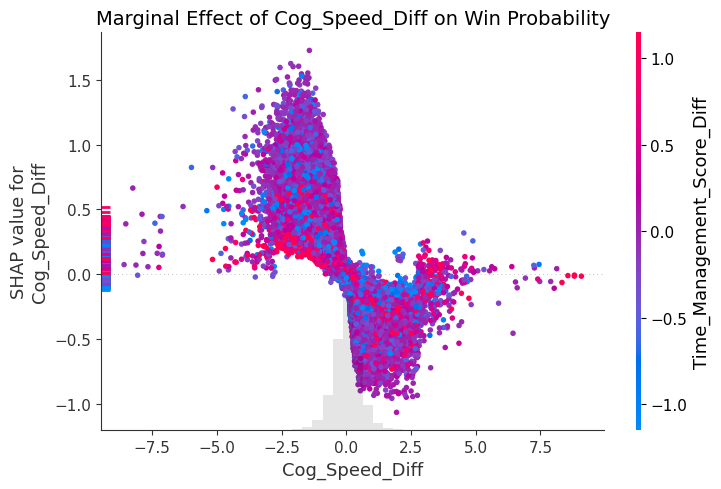

In [13]:
# ==========================================
# 1. 数据清洗与二分类转换
# ==========================================
# 假设你的表叫 game_features
df_model = game_features.copy()

# 【关键】剔除平局，留下最纯粹的 胜(1) vs 负(-1) 的对抗数据
df_model = df_model[df_model['Target'] != 0].copy()

# 将 -1 (负) 统一映射为 0，符合标准二分类逻辑 (1=Win, 0=Lose)
df_model['Target'] = df_model['Target'].apply(lambda x: 1 if x == 1 else 0)

# 定义特征矩阵 X 和标签 y
# 剔除掉不能用来预测的 ID 列和目标列
drop_cols = ['uid', 'Player', 'Target', 'Δi', 'Δi_Diff']
features = [c for c in df_model.columns if c not in drop_cols]

X = df_model[features]
y = df_model['Target']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. 训练 LightGBM 模型
# ==========================================
clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])

# ==========================================
# 3. 模型基础评估
# ==========================================
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\n【单局胜负预测结果】")
print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ==========================================
# ==========================================
# 4. SHAP 进阶分析 (修正空白图问题)
# ==========================================
explainer = shap.TreeExplainer(clf)
shap_values_obj = explainer(X_test) 

# --- 图 1：全局蜂群图 (Beeswarm) ---
plt.figure(figsize=(10, 6))
# 【关键修复】：必须加上 show=False
shap.plots.beeswarm(shap_values_obj, max_display=15, show=False)
plt.title("Global Feature Impact on Win Probability", fontsize=14)
plt.tight_layout()
plt.show()

# --- 图 2：单局微观剖析 - 瀑布图 (Waterfall Plot) ---
sample_idx = 0

plt.figure(figsize=(8, 6))
# 【关键修复】：必须加上 show=False
shap.plots.waterfall(shap_values_obj[sample_idx], max_display=10, show=False)
plt.title(f"Local Explanation of Win Probability (Sample {sample_idx})", fontsize=14)
plt.tight_layout()
plt.show()

# --- 图 3：特征依赖图 (Dependence Plot) ---
plt.figure(figsize=(8, 6))
# 【关键修复】：必须加上 show=False
shap.plots.scatter(shap_values_obj[:, "Cog_Speed_Diff"], color=shap_values_obj, show=False)
plt.title("Marginal Effect of Cog_Speed_Diff on Win Probability", fontsize=14)
plt.tight_layout()
plt.show()


--- 仅使用 ELO 预测 ---
[LightGBM] [Info] Number of positive: 734019, number of negative: 734813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 1468832, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499730 -> initscore=-0.001081
[LightGBM] [Info] Start training from score -0.001081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.499656

【单局胜负预测结果】
准确率 (Accuracy): 0.7696
AUC Score: 0.8365


<Figure size 1000x600 with 0 Axes>

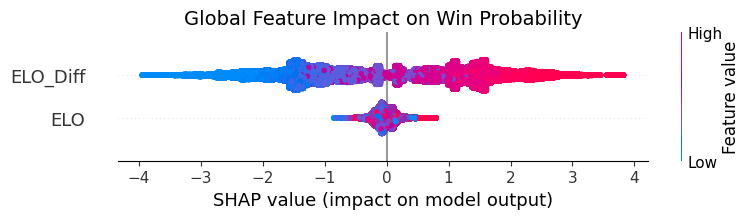

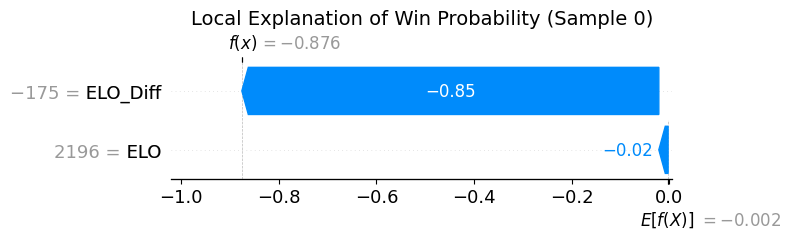


[提示] 当前特征集不包含 Cog_Speed_Diff，跳过特征依赖图绘制。

--- 使用 ELO 和其他特征预测 ---
[LightGBM] [Info] Number of positive: 734019, number of negative: 734813
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 1468832, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499730 -> initscore=-0.001081
[LightGBM] [Info] Start training from score -0.001081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.0580715

【单局胜负预测结果】
准确率 (Accuracy): 0.9813
AUC Score: 0.9974


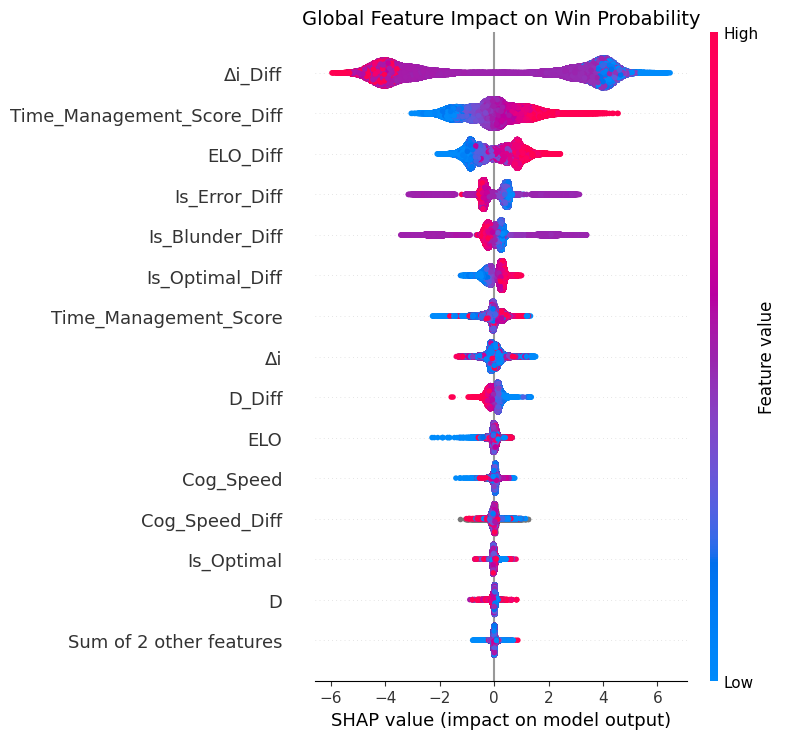

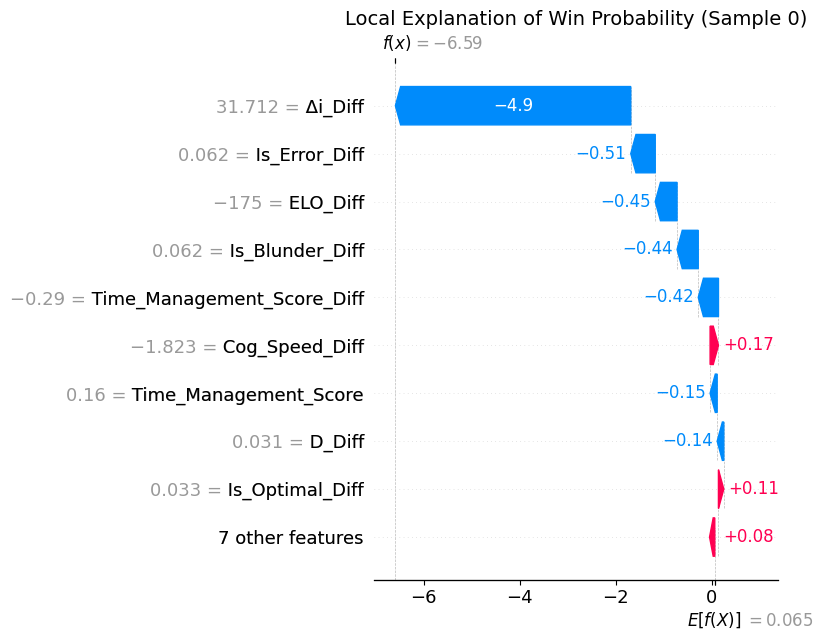

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


<Figure size 800x600 with 0 Axes>

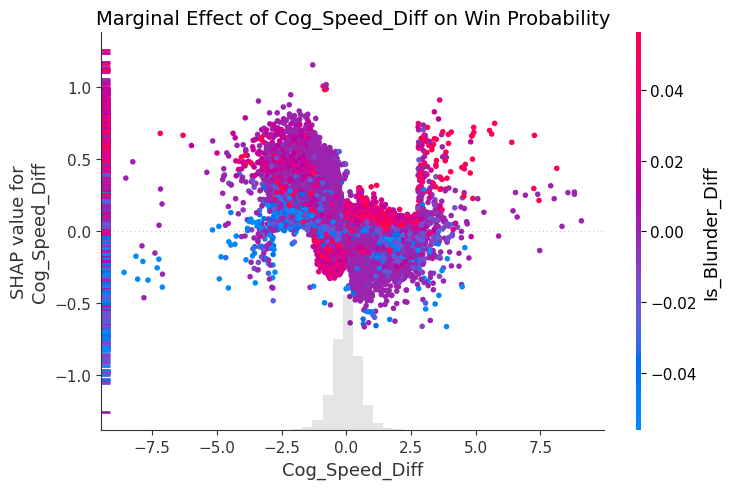

In [16]:
# ==========================================
# 1. 数据清洗与二分类转换
# ==========================================
# 假设你的表叫 game_features
df_model = game_features.copy()

# 【关键】剔除平局，留下最纯粹的 胜(1) vs 负(-1) 的对抗数据
df_model = df_model[df_model['Target'] != 0].copy()

# 将 -1 (负) 统一映射为 0，符合标准二分类逻辑 (1=Win, 0=Lose)
df_model['Target'] = df_model['Target'].apply(lambda x: 1 if x == 1 else 0)

# 定义可以作为特征的列（默认包括 ELO 相关特征）
default_features = ['ELO', 'ELO_Diff']  # 只使用 ELO 相关特征
additional_features = ['Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 
                       'Cog_Speed', 'Time_Management_Score', 
                       'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 
                       'Δi_Diff', 'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff']  # 其他特征

# 将ELO特征和其他特征合并，可以手动修改此列表来选择不同的特征
def get_features(include_additional=True):
    if include_additional:
        return default_features + additional_features  # 包括ELO和其他特征
    else:
        return default_features  # 只包含ELO相关特征

# 划分特征矩阵 X 和标签 y
def prepare_data(include_additional=True):
    features = get_features(include_additional)
    X = df_model[features]
    y = df_model['Target']
    return X, y

# ==========================================
# 2. 模型训练与评估
# ==========================================
def train_and_evaluate(include_additional=True):
    # 准备数据
    X, y = prepare_data(include_additional)

    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 训练 LightGBM 模型
    clf = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])

    # 模型评估
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    print("\n【单局胜负预测结果】")
    print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    
    return clf, X_test, y_test, y_pred, y_prob

# ==========================================
# 3. SHAP 进阶分析
# ==========================================
def shap_analysis(clf, X_test):
    # 1. 使用 SHAP 解释器
    explainer = shap.TreeExplainer(clf)
    
    # 2. 【核心修复】直接调用 explainer 生成完整的 Explanation 对象
    # 这会自动打包 values, base_values 和 data，避免手动拼接引发的维度降级
    shap_explanation = explainer(X_test) 
    
    # 3. 处理潜在的维度问题（兼容不同版本的 SHAP）
    # 如果输出是三维的 (样本数, 特征数, 类别数)，则提取正类 (index 1)
    # 如果输出是二维的 (样本数, 特征数)，则说明已经是目标类，直接使用即可
    if len(shap_explanation.shape) == 3:
        shap_explanation = shap_explanation[:, :, 1]

    # --- 图 1：全局蜂群图 (Beeswarm) --- 
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_explanation, max_display=15, show=False) 
    plt.title("Global Feature Impact on Win Probability", fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 图 2：单局微观剖析 - 瀑布图 (Waterfall Plot) --- 
    sample_idx = 0  
    plt.figure(figsize=(8, 6))
    # 瀑布图需要传入【单个样本】，这里通过索引切片是完全正确的
    shap.plots.waterfall(shap_explanation[sample_idx], max_display=10, show=False)
    plt.title(f"Local Explanation of Win Probability (Sample {sample_idx})", fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 图 3：特征依赖图 (Dependence Plot) --- 
    # 检查特征是否在当前数据集中（防止仅使用 ELO 预测时找不到 Cog_Speed_Diff 报错）
    feature_to_plot = "Cog_Speed_Diff"
    if feature_to_plot in X_test.columns:
        plt.figure(figsize=(8, 6))
        shap.plots.scatter(shap_explanation[:, feature_to_plot], color=shap_explanation, show=False)
        plt.title(f"Marginal Effect of {feature_to_plot} on Win Probability", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n[提示] 当前特征集不包含 {feature_to_plot}，跳过特征依赖图绘制。")

# ==========================================
# 4. 进行两种模型的训练与评估
# ==========================================
print("\n--- 仅使用 ELO 预测 ---")
clf_elo, X_test_elo, y_test_elo, y_pred_elo, y_prob_elo = train_and_evaluate(include_additional=False)
shap_analysis(clf_elo, X_test_elo)

print("\n--- 使用 ELO 和其他特征预测 ---")
clf_all, X_test_all, y_test_all, y_pred_all, y_prob_all = train_and_evaluate(include_additional=True)
shap_analysis(clf_all, X_test_all)

用选手的历史信息，去预测新的比赛的结果

In [17]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'Cog_Speed', 'Time_Management_Score', 'ELO', 'Target', 'ELO_Diff',
       'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff',
       'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff'],
      dtype='object')

In [18]:
# 匹配上日期信息
import sqlite3
import pandas as pd

# 1. 建立数据库连接
db_path = r'C:\sqlite3\chess.db'
conn = sqlite3.connect(db_path)

# 2. 仅提取必要的 uid 和 Date 列
# 假设 games 表中存储日期的列名确实是 'Date'
query = "SELECT uid, Date FROM games"
df_dates = pd.read_sql_query(query, conn)

# 关闭连接
conn.close()

# 3. 将日期信息合并到你的 game_features 表中
# 假设你现有的 DataFrame 变量名是 df_features
game_features = pd.merge(game_features, df_dates, on='uid', how='left')

# 4. 转换日期格式（非常重要！）
# 象棋数据库中的日期通常是 '2023.01.15' 这种字符串，必须转为 datetime 对象才能正确排序
game_features['Date'] = pd.to_datetime(game_features['Date'], format='%Y.%m.%d', errors='coerce')

# 检查是否有缺失日期
missing_dates = game_features['Date'].isna().sum()
if missing_dates > 0:
    print(f"警告：有 {missing_dates} 局游戏未能匹配到日期信息。")

In [19]:
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,Cog_Speed,Time_Management_Score,ELO,Target,ELO_Diff,Is_Optimal_Diff,Is_Error_Diff,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_Diff,Time_Management_Score_Diff,Date
0,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,0.347500,0.22,2637.0,1.0,460.0,0.076923,-0.153846,-0.153846,-36.307693,-0.113450,-0.186136,-0.02,2025-04-01
1,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.533636,0.24,2177.0,-1.0,-460.0,-0.076923,0.153846,0.153846,36.307693,0.113450,0.186136,0.02,2025-04-01
2,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.396667,-0.06,2195.0,-1.0,-444.0,-0.109890,0.236264,0.230769,768.620911,-0.061178,0.065417,-0.20,2025-04-01
3,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,0.331250,0.14,2639.0,1.0,444.0,0.109890,-0.236264,-0.230769,-768.620911,0.061178,-0.065417,0.20,2025-04-01
4,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,0.229286,0.41,2049.0,-1.0,-558.0,0.236842,0.005263,0.055263,32.728951,-0.071206,-0.137714,0.11,2025-04-01


In [20]:
# 1. 排序：确保时间顺序（统一将结果赋给 df）
df = game_features.sort_values(by=['Player', 'Date', 'uid']).reset_index(drop=True)

# 2. 定义需要计算历史状态的基础特征
base_features = [
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 
    'Cog_Speed', 'Time_Management_Score'
]

# 生成简化的历史特征列名
historical_cols = [f"{col}_Hist" for col in base_features]

df[historical_cols] = df.groupby('Player')[base_features].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=10).mean()
)

df_model = df.dropna(subset=historical_cols).copy()

# 5. 提取必需列并自连接合并对手信息
cols_to_keep = ['uid', 'Player', 'ELO', 'Target'] + historical_cols
df_base = df_model[cols_to_keep]

df_match = pd.merge(
    df_base, 
    df_base, 
    on='uid', 
    suffixes=('', '_Opp')
)
df_match = df_match[df_match['Player'] != df_match['Player_Opp']].copy()

# 计算差值
df_match['ELO_Diff'] = df_match['ELO'] - df_match['ELO_Opp']

for col in base_features:
    hist_col_self = f"{col}_Hist"
    hist_col_opp = f"{col}_Hist_Opp"
    diff_col_name = f"{col}_Hist_Diff"
    
    df_match[diff_col_name] = df_match[hist_col_self] - df_match[hist_col_opp]

# 现在的 df_match 就完全符合你的命名期望了

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26500\2259494109.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[historical_cols] = df.groupby('Player')[base_features].transform(


In [21]:
df_match.to_parquet('df_match.parquet')

In [22]:
df_match.head()

,uid,Player,ELO,Target,Is_Optimal_Hist,Is_Error_Hist,Is_Blunder_Hist,Δi_Hist,D_Hist,Cog_Speed_Hist,...,Cog_Speed_Hist_Opp,Time_Management_Score_Hist_Opp,ELO_Diff,Is_Optimal_Hist_Diff,Is_Error_Hist_Diff,Is_Blunder_Hist_Diff,Δi_Hist_Diff,D_Hist_Diff,Cog_Speed_Hist_Diff,Time_Management_Score_Hist_Diff
1,232968,Aarav Sinha,2354.0,-1.0,0.590213,0.093032,0.044955,92.722626,0.511147,0.657345,...,0.355774,0.314,-187.0,0.014133,0.048571,0.013969,11.548091,-0.009470,0.301571,-0.331
3,239353,Aarav Sinha,2351.0,-1.0,0.559657,0.101365,0.048659,130.482810,0.507370,0.652864,...,0.628961,-0.278,-307.0,-0.016356,0.013723,-0.010626,-80.487549,0.051948,0.023903,0.129
5,239948,Aarav Sinha,2367.0,1.0,0.565339,0.106668,0.058129,173.889628,0.507946,0.609502,...,0.794702,-0.434,-165.0,0.028137,0.058465,0.025795,-8.058334,-0.041127,-0.185201,0.352
7,240104,Aarav Sinha,2363.0,-1.0,0.568512,0.109900,0.060009,173.662189,0.497353,0.628835,...,0.662069,-0.343,-241.0,0.060495,0.032615,0.027778,2.178934,0.009008,-0.033234,0.250
9,240473,Aarav Sinha,2357.0,-1.0,0.557786,0.097884,0.051219,170.538480,0.510793,0.595666,...,0.519100,-0.423,-176.0,0.015046,0.032504,0.009685,67.284745,0.037877,0.076565,0.383


当成二分类

In [23]:
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ======================
# 1. 加载你的数据 + 二分类清洗（剔除平局，只留胜负）
# ======================
df_match = df_match.copy()
# 🔥 核心：剔除平局 Target=0.0，只保留输(-1)和赢(1)
df_match = df_match[df_match['Target'] != 0.0].reset_index(drop=True)

# 定义要丢弃的列（和你原来完全一致）
drop_cols = ['uid', 'Player', 'Player_Opp', 'Date', 'Target', 'Target_Opp']
features = [col for col in df_match.columns if col not in drop_cols]

# 特征和标签
X = df_match[features]
y = df_match['Target'] 

# 🔥 二分类标签映射：负(-1.0)->0，胜(1.0)->1
label_mapping = {-1.0: 0, 1.0: 1}
y_mapped = y.map(label_mapping)

# ======================
# 2. 时序划分（保持你原来的逻辑不变）
# ======================
split_index = int(len(df_match) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y_mapped.iloc[:split_index], y_mapped.iloc[split_index:]

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"训练集标签分布:\n{y_train.value_counts()}")

# ======================
# 3. 二分类 LightGBM 模型（修改自多分类）
# ======================
clf = lgb.LGBMClassifier(
    n_estimators=200,      
    learning_rate=0.05,    
    max_depth=5,           
    objective='binary',  # 🔥 改为二分类
    random_state=42,
    n_jobs=-1              
)

# 训练模型
clf.fit(X_train, y_train)

# ======================
# 4. 二分类预测与评估
# ======================
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # 预测为赢的概率

print("\n=== 模型评估报告（二分类：只看胜负）===")
target_names = ['Loss (-1.0)', 'Win (1.0)']
print(classification_report(y_test, y_pred, target_names=target_names))

# 二分类核心指标（比多分类更直观）
print(f"\n准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC (ROC): {roc_auc_score(y_test, y_prob):.4f}")

训练集大小: (1329144, 24), 测试集大小: (332286, 24)
训练集标签分布:
Target
1    675614
0    653530
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 675614, number of negative: 653530
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 1329144, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508308 -> initscore=0.033233
[LightGBM] [Info] Start training from score 0.033233
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

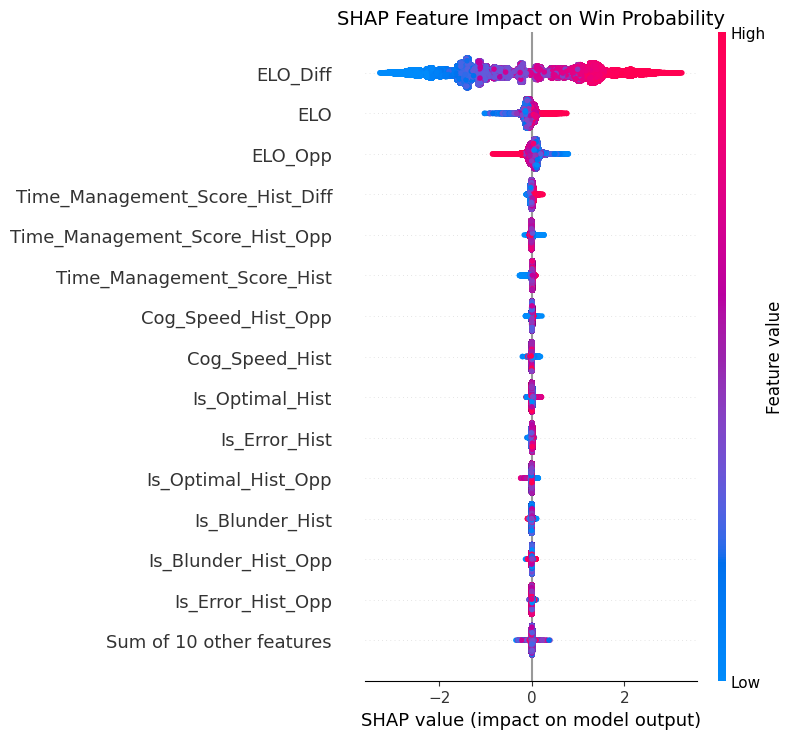

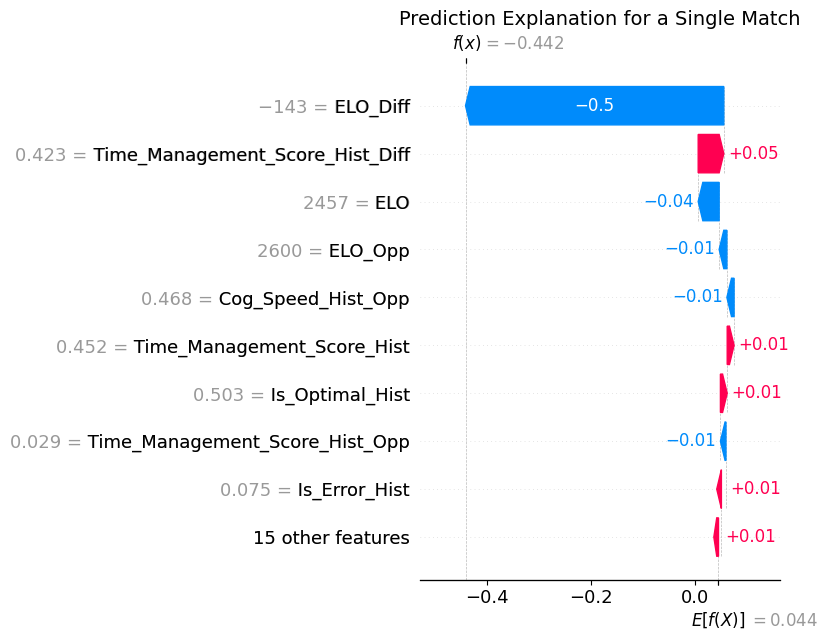

<Figure size 800x500 with 0 Axes>

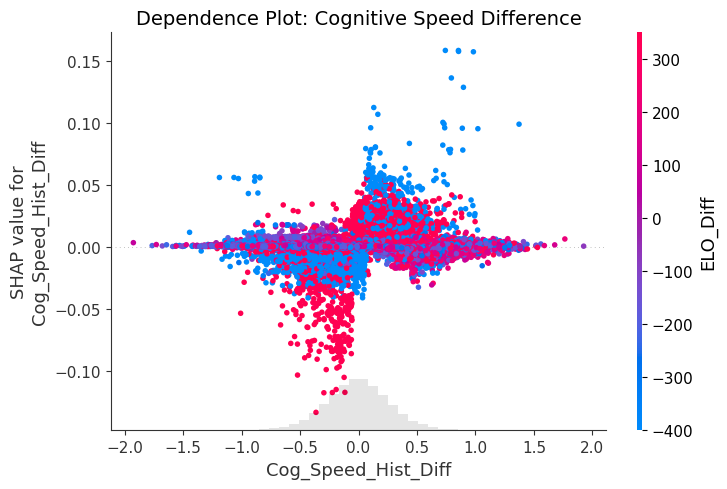

In [24]:
# 移除中文字体设置，保持纯英文
plt.style.use('default') 

# ======================
# SHAP Explainer (Using modern API for Explanation objects)
# ======================
# 注意：使用 shap.Explainer 可以直接生成带有基线值和特征名称的 Explanation 对象
explainer = shap.Explainer(clf)
shap_values_obj = explainer(X_test)

# 如果你的 lightGBM 版本导致 SHAP 输出具有第三个维度(二分类的两个类)，提取正类(Index 1)
if len(shap_values_obj.shape) == 3:
    shap_values_obj = shap_values_obj[:, :, 1]

# ======================
# Figure 1: SHAP Beeswarm Plot (The most important one for direction)
# ======================
plt.figure(figsize=(10, 6))
# 默认就是蜂群图，既有重要性排序，又有正负方向
shap.plots.beeswarm(shap_values_obj, max_display=15, show=False)
plt.title("SHAP Feature Impact on Win Probability", fontsize=14)
plt.tight_layout()
plt.show()

# ======================
# Figure 2: Single Match Waterfall Plot
# ======================
plt.figure(figsize=(9, 6))
# 观察测试集中第 0 个样本（第一局比赛）是如何被预测的
shap.plots.waterfall(shap_values_obj[0], max_display=10, show=False)
plt.title("Prediction Explanation for a Single Match", fontsize=14)
plt.tight_layout()
plt.show()

# ======================
# Figure 3: Dependence Plot (Trend for a specific feature)
# ======================
plt.figure(figsize=(8, 5))
# 这里以认知速度差为例，你可以换成你感兴趣的任何列
shap.plots.scatter(shap_values_obj[:, "Cog_Speed_Hist_Diff"], color=shap_values_obj[:, "ELO_Diff"], show=False)
plt.title("Dependence Plot: Cognitive Speed Difference", fontsize=14)
plt.tight_layout()
plt.show()